In [2]:
#Download the dataset
import os
from pathlib import Path
import zipfile

def download_voc_from_kaggle():
    """Download PASCAL VOC 2012 from Kaggle"""
    
    data_dir = Path("./data")
    data_dir.mkdir(exist_ok=True)
    
    voc_dir = data_dir / "VOCdevkit"
    
    # Check if already exists
    if voc_dir.exists():
        print("Dataset already exists!")
        return str(voc_dir)
    
    print("Downloading PASCAL VOC 2012 from Kaggle...")
    
    # Download using kaggle API
    # Dataset: https://www.kaggle.com/datasets/huanghanchina/pascal-voc-2012
    os.system('kaggle datasets download -d huanghanchina/pascal-voc-2012 -p ./data')
    
    # Extract
    zip_path = data_dir / "pascal-voc-2012.zip"
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(data_dir)
    
    # Cleanup
    zip_path.unlink()
    print("Download complete!")
    
    return str(voc_dir)

voc_path = download_voc_from_kaggle()

Dataset already exists!


Now Let's Start with Exploration of the data

In [3]:
# Essential imports
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import cv2
from collections import Counter
from tqdm import tqdm
import pandas as pd

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Imports successful!")
print(f"Current directory: {os.getcwd()}")

✓ Imports successful!
Current directory: C:\Users\daksh\Desktop\ML Course projects\CV Bootcamp


In [4]:
# Define paths
data_root = Path("./data")
voc_root = data_root / "VOCdevkit" / "VOC2012"

# Check if dataset exists
if not voc_root.exists():
    print("Dataset not found!")
    print(f"Expected location: {voc_root}")
    print("\nPlease ensure the Kaggle download is extracted to ./data/")
else:
    print("Dataset found!")
    
# Define key directories
image_dir = voc_root / "JPEGImages"
mask_dir = voc_root / "SegmentationClass"
instance_dir = voc_root / "SegmentationObject"
annotation_dir = voc_root / "Annotations"

# Verify all directories exist
dirs_to_check = {
    "Images": image_dir,
    "Segmentation Masks": mask_dir,
    "Instance Masks": instance_dir,
    "Annotations": annotation_dir
}

print("\n📁 Directory Structure:")
for name, path in dirs_to_check.items():
    exists = "✓" if path.exists() else "✗"
    print(f"   {exists} {name}: {path}")

Dataset found!

📁 Directory Structure:
   ✓ Images: data\VOCdevkit\VOC2012\JPEGImages
   ✓ Segmentation Masks: data\VOCdevkit\VOC2012\SegmentationClass
   ✓ Instance Masks: data\VOCdevkit\VOC2012\SegmentationObject
   ✓ Annotations: data\VOCdevkit\VOC2012\Annotations


In [5]:
# Count files in each directory
def count_files(directory, extension):
    """Count files with specific extension in directory"""
    return len(list(directory.glob(f"*.{extension}")))

# Get counts
num_images = count_files(image_dir, "jpg")
num_masks = count_files(mask_dir, "png")
num_instances = count_files(instance_dir, "png")

print("=" * 60)
print("📊 PASCAL VOC 2012 DATASET STATISTICS")
print("=" * 60)
print(f"\n📸 Total Images:              {num_images:,}")
print(f"🎭 Segmentation Masks:        {num_masks:,}")
print(f"👤 Instance Masks:            {num_instances:,}")
print(f"\n📦 Total Dataset Size:        ~2 GB")
print(f"🏷️  Number of Classes:         21 (including background)")
print("=" * 60)

📊 PASCAL VOC 2012 DATASET STATISTICS

📸 Total Images:              17,125
🎭 Segmentation Masks:        2,913
👤 Instance Masks:            2,913

📦 Total Dataset Size:        ~2 GB
🏷️  Number of Classes:         21 (including background)


In [6]:
# PASCAL VOC 2012 Classes
VOC_CLASSES = [
    'background',      # 0
    'aeroplane',       # 1
    'bicycle',         # 2
    'bird',            # 3
    'boat',            # 4
    'bottle',          # 5
    'bus',             # 6
    'car',             # 7
    'cat',             # 8
    'chair',           # 9
    'cow',             # 10
    'diningtable',     # 11
    'dog',             # 12
    'horse',           # 13
    'motorbike',       # 14
    'person',          # 15
    'pottedplant',     # 16
    'sheep',           # 17
    'sofa',            # 18
    'train',           # 19
    'tvmonitor'        # 20
]

# Color palette for visualization (VOC standard colors)
VOC_COLORMAP = np.array([
    [0, 0, 0],         # background - black
    [128, 0, 0],       # aeroplane - maroon
    [0, 128, 0],       # bicycle - green
    [128, 128, 0],     # bird - olive
    [0, 0, 128],       # boat - navy
    [128, 0, 128],     # bottle - purple
    [0, 128, 128],     # bus - teal
    [128, 128, 128],   # car - gray
    [64, 0, 0],        # cat - dark red
    [192, 0, 0],       # chair - red
    [64, 128, 0],      # cow - lime
    [192, 128, 0],     # diningtable - yellow
    [64, 0, 128],      # dog - purple
    [192, 0, 128],     # horse - magenta
    [64, 128, 128],    # motorbike - cyan
    [192, 128, 128],   # person - pink
    [0, 64, 0],        # pottedplant - dark green
    [128, 64, 0],      # sheep - brown
    [0, 192, 0],       # sofa - bright green
    [128, 192, 0],     # train - yellow-green
    [0, 64, 128]       # tvmonitor - blue
])

print("📋 PASCAL VOC 2012 Classes:")
print("=" * 60)
for idx, cls in enumerate(VOC_CLASSES):
    color_rgb = VOC_COLORMAP[idx]
    print(f"   {idx:2d}: {cls:15s} | RGB: {color_rgb}")
print("=" * 60)

📋 PASCAL VOC 2012 Classes:
    0: background      | RGB: [0 0 0]
    1: aeroplane       | RGB: [128   0   0]
    2: bicycle         | RGB: [  0 128   0]
    3: bird            | RGB: [128 128   0]
    4: boat            | RGB: [  0   0 128]
    5: bottle          | RGB: [128   0 128]
    6: bus             | RGB: [  0 128 128]
    7: car             | RGB: [128 128 128]
    8: cat             | RGB: [64  0  0]
    9: chair           | RGB: [192   0   0]
   10: cow             | RGB: [ 64 128   0]
   11: diningtable     | RGB: [192 128   0]
   12: dog             | RGB: [ 64   0 128]
   13: horse           | RGB: [192   0 128]
   14: motorbike       | RGB: [ 64 128 128]
   15: person          | RGB: [192 128 128]
   16: pottedplant     | RGB: [ 0 64  0]
   17: sheep           | RGB: [128  64   0]
   18: sofa            | RGB: [  0 192   0]
   19: train           | RGB: [128 192   0]
   20: tvmonitor       | RGB: [  0  64 128]


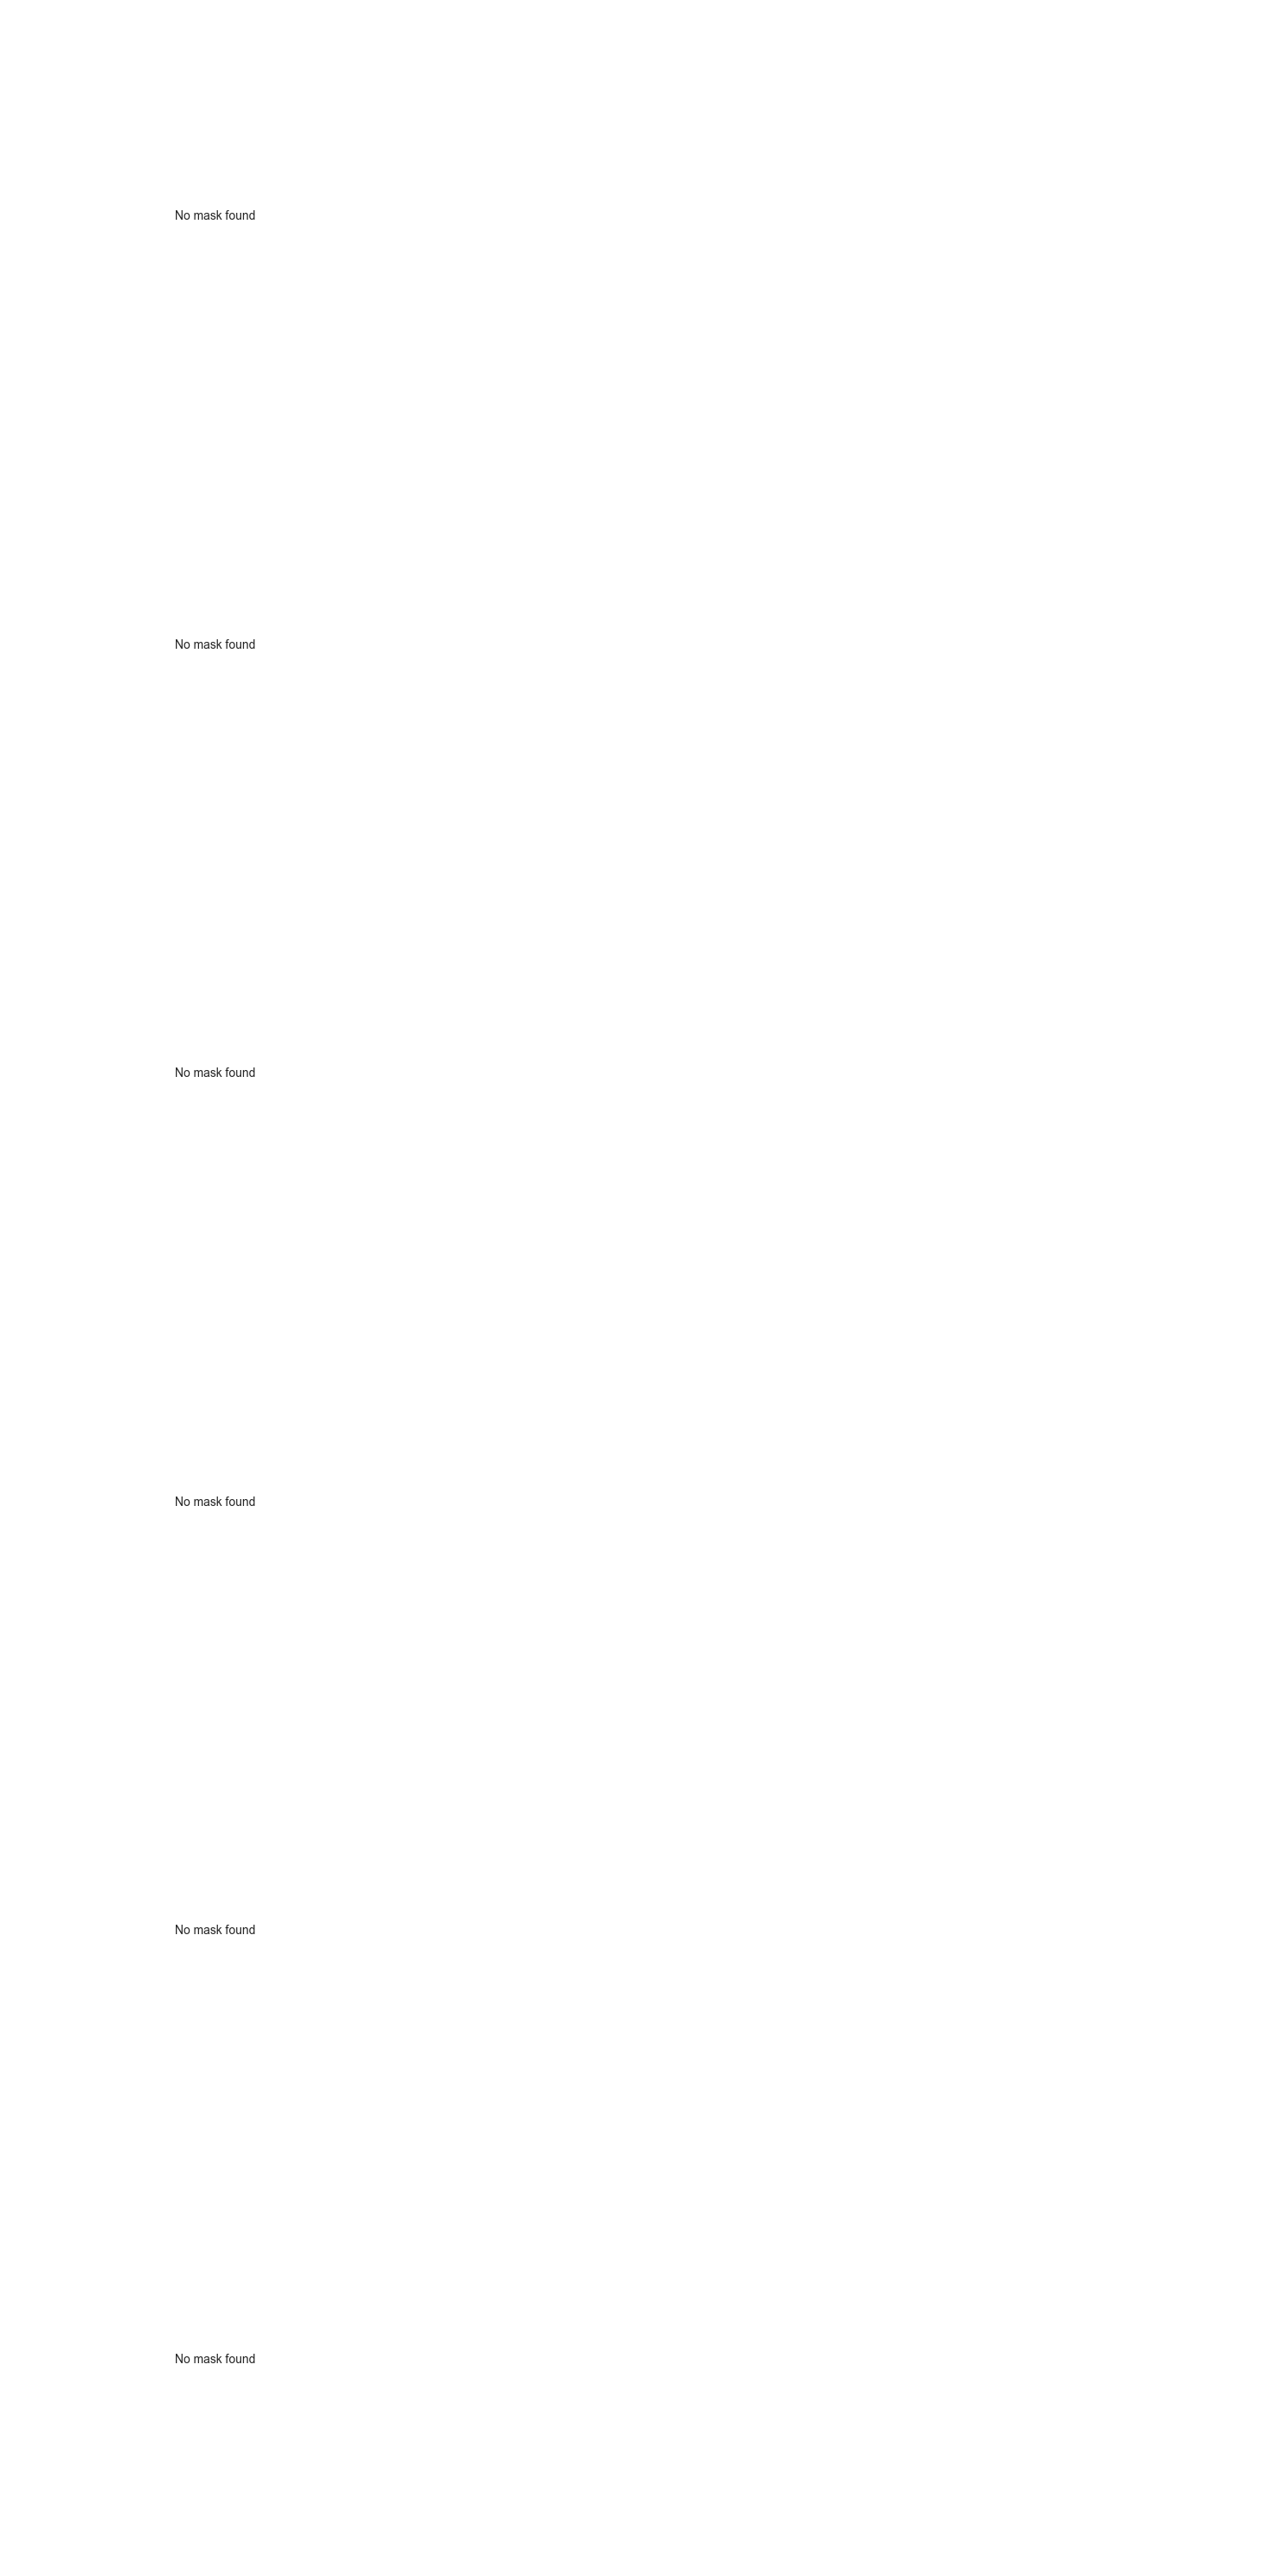

✓ Visualization saved as 'sample_visualizations.png'


In [7]:
def visualize_random_samples(num_samples=6):
    """Visualize random image-mask pairs"""
    
    # Get random images
    image_files = sorted(list(image_dir.glob("*.jpg")))
    sample_indices = np.random.choice(len(image_files), num_samples, replace=False)
    sample_files = [image_files[i] for i in sample_indices]
    
    # Create figure
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5*num_samples))
    
    for idx, img_path in enumerate(sample_files):
        # Load image
        image = Image.open(img_path).convert('RGB')
        image_np = np.array(image)
        
        # Load mask
        mask_path = mask_dir / f"{img_path.stem}.png"
        
        if mask_path.exists():
            mask = Image.open(mask_path)
            mask_np = np.array(mask)
            
            # Create colored mask
            colored_mask = np.zeros((*mask_np.shape, 3), dtype=np.uint8)
            for class_id in range(21):
                colored_mask[mask_np == class_id] = VOC_COLORMAP[class_id]
            
            # Create overlay
            overlay = cv2.addWeighted(image_np, 0.6, colored_mask, 0.4, 0)
            
            # Get unique classes in this image
            unique_classes = np.unique(mask_np)
            class_names = [VOC_CLASSES[c] for c in unique_classes if c < len(VOC_CLASSES)]
            
            # Plot
            axes[idx, 0].imshow(image_np)
            axes[idx, 0].set_title(f"Original Image\n{img_path.stem}", fontsize=10)
            axes[idx, 0].axis('off')
            
            axes[idx, 1].imshow(colored_mask)
            axes[idx, 1].set_title(f"Segmentation Mask\nClasses: {', '.join(class_names)}", fontsize=9)
            axes[idx, 1].axis('off')
            
            axes[idx, 2].imshow(overlay)
            axes[idx, 2].set_title("Overlay", fontsize=10)
            axes[idx, 2].axis('off')
        else:
            axes[idx, 0].text(0.5, 0.5, 'No mask found', ha='center', va='center')
            axes[idx, 0].axis('off')
            axes[idx, 1].axis('off')
            axes[idx, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig('sample_visualizations.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Visualization saved as 'sample_visualizations.png'")

# Visualize samples
visualize_random_samples(num_samples=6)

Analyzing 500 random images...


Processing: 100%|████████████████████████████████████████████████████████████████████| 500/500 [00:05<00:00, 83.87it/s]



📐 IMAGE DIMENSION STATISTICS
Width  - Min:  247 | Max:  500 | Avg: 467.6
Height - Min:  111 | Max:  500 | Avg: 385.9
Aspect Ratio - Min: 0.53 | Max: 4.50 | Avg: 1.27


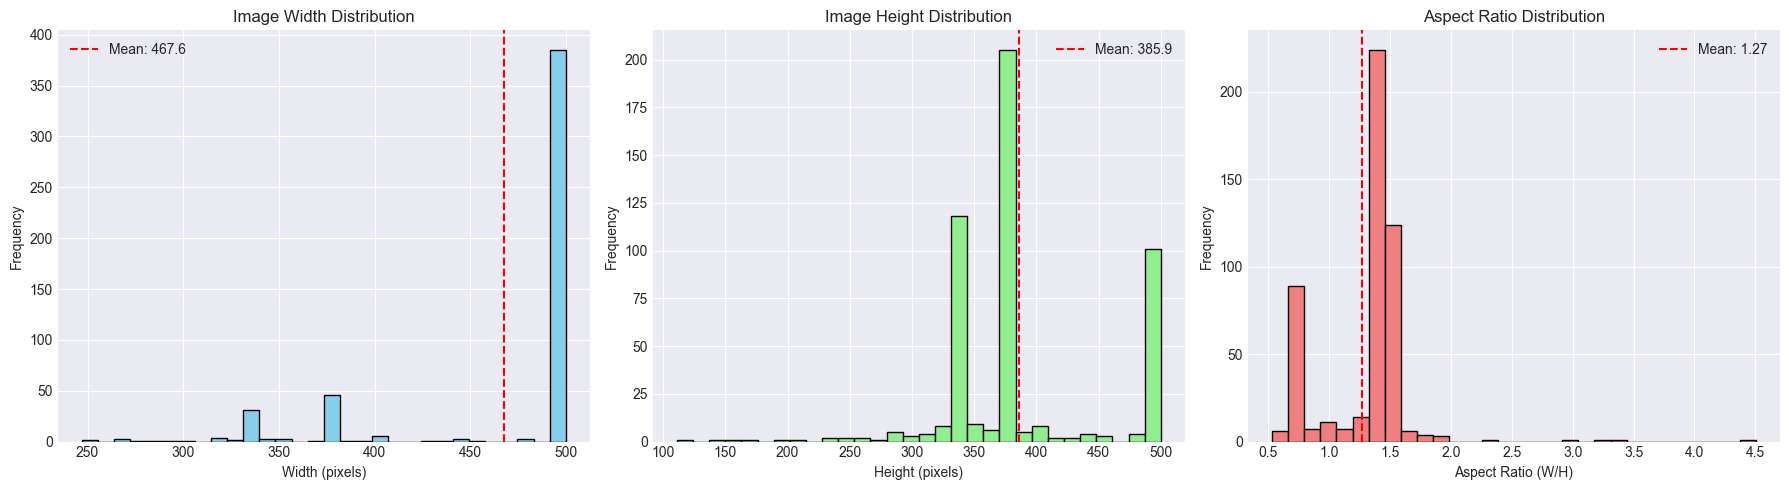

✓ Analysis saved as 'dimension_analysis.png'


In [8]:
def analyze_image_dimensions(sample_size=500):
    """Analyze image dimensions distribution"""
    
    print(f"Analyzing {sample_size} random images...")
    
    image_files = list(image_dir.glob("*.jpg"))
    sample_files = np.random.choice(image_files, min(sample_size, len(image_files)), replace=False)
    
    widths = []
    heights = []
    aspect_ratios = []
    
    for img_path in tqdm(sample_files, desc="Processing"):
        img = Image.open(img_path)
        w, h = img.size
        widths.append(w)
        heights.append(h)
        aspect_ratios.append(w / h)
    
    # Statistics
    print("\n📐 IMAGE DIMENSION STATISTICS")
    print("=" * 60)
    print(f"Width  - Min: {min(widths):4d} | Max: {max(widths):4d} | Avg: {np.mean(widths):.1f}")
    print(f"Height - Min: {min(heights):4d} | Max: {max(heights):4d} | Avg: {np.mean(heights):.1f}")
    print(f"Aspect Ratio - Min: {min(aspect_ratios):.2f} | Max: {max(aspect_ratios):.2f} | Avg: {np.mean(aspect_ratios):.2f}")
    print("=" * 60)
    
    # Plot distributions
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    axes[0].hist(widths, bins=30, color='skyblue', edgecolor='black')
    axes[0].set_xlabel('Width (pixels)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Image Width Distribution')
    axes[0].axvline(np.mean(widths), color='red', linestyle='--', label=f'Mean: {np.mean(widths):.1f}')
    axes[0].legend()
    
    axes[1].hist(heights, bins=30, color='lightgreen', edgecolor='black')
    axes[1].set_xlabel('Height (pixels)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Image Height Distribution')
    axes[1].axvline(np.mean(heights), color='red', linestyle='--', label=f'Mean: {np.mean(heights):.1f}')
    axes[1].legend()
    
    axes[2].hist(aspect_ratios, bins=30, color='lightcoral', edgecolor='black')
    axes[2].set_xlabel('Aspect Ratio (W/H)')
    axes[2].set_ylabel('Frequency')
    axes[2].set_title('Aspect Ratio Distribution')
    axes[2].axvline(np.mean(aspect_ratios), color='red', linestyle='--', label=f'Mean: {np.mean(aspect_ratios):.2f}')
    axes[2].legend()
    
    plt.tight_layout()
    plt.savefig('dimension_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Analysis saved as 'dimension_analysis.png'")

analyze_image_dimensions(sample_size=500)

Analyzing class distribution in 1000 masks...


Processing masks: 100%|███████████████████████████████████████████████████████████| 1000/1000 [00:09<00:00, 110.07it/s]



📊 CLASS DISTRIBUTION
 Class ID  Class Name  Image Count  Total Pixels
        0  background          995     123985244
       15      person          301       8539701
        8         cat           93       5265220
        9       chair           93       1477229
        7         car           79       2240767
       19       train           75       3541887
       12         dog           73       2643960
        3        bird           73       1496054
        5      bottle           64       1188866
        1   aeroplane           61       1355249
       18        sofa           59       2396238
       20   tvmonitor           59       1771377
       16 pottedplant           58       1052601
        2     bicycle           57        713488
       11 diningtable           55       2298535
       10         cow           52       2021323
       14   motorbike           49       1804694
        4        boat           47        973702
       13       horse           42       130649

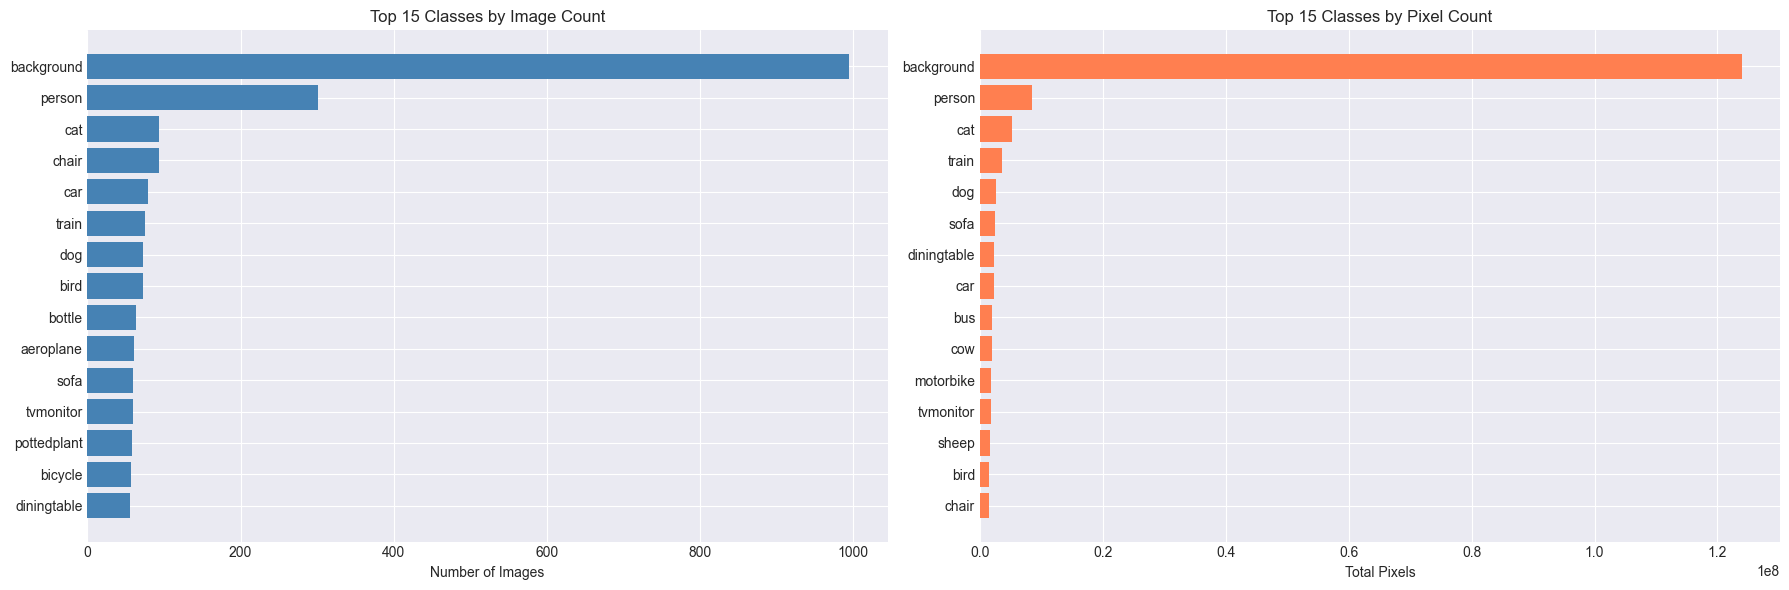

✓ Analysis saved as 'class_distribution.png'


In [9]:
def analyze_class_distribution(sample_size=1000):
    """Analyze distribution of classes across masks"""
    
    print(f"Analyzing class distribution in {sample_size} masks...")
    
    mask_files = list(mask_dir.glob("*.png"))
    sample_files = np.random.choice(mask_files, min(sample_size, len(mask_files)), replace=False)
    
    class_counts = Counter()
    class_pixel_counts = Counter()
    
    for mask_path in tqdm(sample_files, desc="Processing masks"):
        mask = np.array(Image.open(mask_path))
        
        # Count occurrences
        unique, counts = np.unique(mask, return_counts=True)
        
        for class_id, pixel_count in zip(unique, counts):
            if class_id < 255:  # Exclude border class (255)
                class_counts[class_id] += 1
                class_pixel_counts[class_id] += pixel_count
    
    # Create dataframe
    data = []
    for class_id in range(21):
        data.append({
            'Class ID': class_id,
            'Class Name': VOC_CLASSES[class_id],
            'Image Count': class_counts.get(class_id, 0),
            'Total Pixels': class_pixel_counts.get(class_id, 0)
        })
    
    df = pd.DataFrame(data)
    df = df.sort_values('Image Count', ascending=False)
    
    print("\n📊 CLASS DISTRIBUTION")
    print("=" * 80)
    print(df.to_string(index=False))
    print("=" * 80)
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # Bar plot - Image count
    top_classes = df.nlargest(15, 'Image Count')
    axes[0].barh(top_classes['Class Name'], top_classes['Image Count'], color='steelblue')
    axes[0].set_xlabel('Number of Images')
    axes[0].set_title('Top 15 Classes by Image Count')
    axes[0].invert_yaxis()
    
    # Bar plot - Pixel count
    top_classes_pixels = df.nlargest(15, 'Total Pixels')
    axes[1].barh(top_classes_pixels['Class Name'], top_classes_pixels['Total Pixels'], color='coral')
    axes[1].set_xlabel('Total Pixels')
    axes[1].set_title('Top 15 Classes by Pixel Count')
    axes[1].invert_yaxis()
    
    plt.tight_layout()
    plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Analysis saved as 'class_distribution.png'")
    
    return df

class_df = analyze_class_distribution(sample_size=1000)

In [10]:
def create_train_val_split(train_ratio=0.8, subset_size=1000, seed=42):
    """Create train/validation split for the project"""
    
    np.random.seed(seed)
    
    # Get all files that have both image and mask
    image_files = set([f.stem for f in image_dir.glob("*.jpg")])
    mask_files = set([f.stem for f in mask_dir.glob("*.png")])
    
    # Intersection - files with both image and mask
    valid_files = sorted(list(image_files & mask_files))
    
    print(f"📂 Dataset Files:")
    print(f"   Total images: {len(image_files)}")
    print(f"   Total masks: {len(mask_files)}")
    print(f"   Valid pairs: {len(valid_files)}")
    
    # Create subset if needed
    if subset_size and subset_size < len(valid_files):
        valid_files = np.random.choice(valid_files, subset_size, replace=False).tolist()
        print(f"   Using subset: {len(valid_files)} files")
    
    # Shuffle and split
    np.random.shuffle(valid_files)
    split_idx = int(len(valid_files) * train_ratio)
    
    train_files = sorted(valid_files[:split_idx])
    val_files = sorted(valid_files[split_idx:])
    
    print(f"\n✓ Split Complete:")
    print(f"   Training:   {len(train_files)} samples ({train_ratio*100:.0f}%)")
    print(f"   Validation: {len(val_files)} samples ({(1-train_ratio)*100:.0f}%)")
    print(f"   Total:      {len(valid_files)} samples")
    
    # Save splits
    splits_dir = Path("./data/splits")
    splits_dir.mkdir(exist_ok=True)
    
    with open(splits_dir / "train.txt", 'w') as f:
        f.write('\n'.join(train_files))
    
    with open(splits_dir / "val.txt", 'w') as f:
        f.write('\n'.join(val_files))
    
    print(f"\n💾 Split files saved to: {splits_dir}")
    print(f"   - train.txt")
    print(f"   - val.txt")
    
    return train_files, val_files

# Create split
train_files, val_files = create_train_val_split(
    train_ratio=0.8,
    subset_size=1000,  # Adjust based on your needs
    seed=42
)

📂 Dataset Files:
   Total images: 17125
   Total masks: 2913
   Valid pairs: 2913
   Using subset: 1000 files

✓ Split Complete:
   Training:   800 samples (80%)
   Validation: 200 samples (20%)
   Total:      1000 samples

💾 Split files saved to: data\splits
   - train.txt
   - val.txt


## Data Preprocessing:

In [11]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.9.0+cpu
CUDA available: False


In [12]:
class VOCSegmentationDataset(Dataset):
    """
    Custom PyTorch Dataset for PASCAL VOC 2012 Segmentation
    """
    def __init__(self, image_dir, mask_dir, file_list, transform=None, target_size=(256, 256)):
        """
        Args:
            image_dir: Path to images directory
            mask_dir: Path to masks directory
            file_list: List of file stems (without extension)
            transform: Albumentations transform pipeline
            target_size: Tuple of (height, width) for resizing
        """
        self.image_dir = Path(image_dir)
        self.mask_dir = Path(mask_dir)
        self.file_list = file_list
        self.transform = transform
        self.target_size = target_size
        
        # VOC Classes
        self.classes = [
            'background', 'aeroplane', 'bicycle', 'bird', 'boat',
            'bottle', 'bus', 'car', 'cat', 'chair', 'cow',
            'diningtable', 'dog', 'horse', 'motorbike', 'person',
            'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
        ]
        
        print(f"✓ Dataset initialized with {len(self.file_list)} samples")
    
    def __len__(self):
        return len(self.file_list)
    
    def __getitem__(self, idx):
        # Get file name
        file_stem = self.file_list[idx]
        
        # Load image
        img_path = self.image_dir / f"{file_stem}.jpg"
        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Load mask
        mask_path = self.mask_dir / f"{file_stem}.png"
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        
        # Handle border class (255) -> convert to background (0)
        mask[mask == 255] = 0
        
        # Apply transforms
        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image = transformed['image']
            mask = transformed['mask']
        
        # Convert mask to long tensor ONLY if it's not already a tensor
        if not isinstance(mask, torch.Tensor):
            mask = torch.from_numpy(mask).long()
        else:
            mask = mask.long()  # Already a tensor, just ensure it's long type
        
        return image, mask
    
    def visualize_sample(self, idx):
        """Visualize a single sample"""
        image, mask = self[idx]
        
        # Convert tensors to numpy for visualization
        if isinstance(image, torch.Tensor):
            image = image.permute(1, 2, 0).cpu().numpy()
            # Denormalize (assuming ImageNet normalization)
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            image = std * image + mean
            image = np.clip(image, 0, 1)
        
        if isinstance(mask, torch.Tensor):
            mask = mask.cpu().numpy()  # Convert tensor to numpy
        
        # Plot
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        axes[0].imshow(image)
        axes[0].set_title(f"Image: {self.file_list[idx]}")
        axes[0].axis('off')
        
        axes[1].imshow(mask, cmap='tab20', vmin=0, vmax=20)
        axes[1].set_title("Segmentation Mask")
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        # Print class info
        unique_classes = np.unique(mask)
        print(f"Classes in this image:")
        for cls_id in unique_classes:
            if cls_id < len(self.classes):
                print(f"  {cls_id}: {self.classes[cls_id]}")

print("✓ Fixed VOCSegmentationDataset class defined")

✓ Fixed VOCSegmentationDataset class defined


In [13]:
def get_training_augmentation(target_size=(256, 256)):
    """
    Training augmentation pipeline using Albumentations
    """
    train_transform = A.Compose([
        A.Resize(height=target_size[0], width=target_size[1]),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.3),
        A.RandomGamma(p=0.3),
        A.GaussNoise(p=0.2),
        A.Blur(blur_limit=3, p=0.2),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ])
    return train_transform

def get_validation_augmentation(target_size=(256, 256)):
    """
    Validation augmentation (only resize and normalize, no random augmentations)
    """
    val_transform = A.Compose([
        A.Resize(height=target_size[0], width=target_size[1]),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ])
    return val_transform

print("\nTraining Augmentations:")
print("  - Resize to 256x256")
print("  - Horizontal Flip (50%)")
print("  - Random Brightness/Contrast (30%)")
print("  - Random Gamma (30%)")
print("  - Gaussian Noise (20%)")
print("  - Blur (20%)")
print("  - Normalization (ImageNet stats)")
print("\nValidation Augmentations:")
print("  - Resize to 256x256")
print("  - Normalization (ImageNet stats)")


Training Augmentations:
  - Resize to 256x256
  - Horizontal Flip (50%)
  - Random Brightness/Contrast (30%)
  - Random Gamma (30%)
  - Gaussian Noise (20%)
  - Blur (20%)
  - Normalization (ImageNet stats)

Validation Augmentations:
  - Resize to 256x256
  - Normalization (ImageNet stats)


In [14]:
# Load split files
splits_dir = Path("./data/splits")

with open(splits_dir / "train.txt", 'r') as f:
    train_files = [line.strip() for line in f.readlines()]

with open(splits_dir / "val.txt", 'r') as f:
    val_files = [line.strip() for line in f.readlines()]

print(f"✓ Loaded split files:")
print(f"   Training: {len(train_files)} samples")
print(f"   Validation: {len(val_files)} samples")

# Define paths
voc_root = Path("./data/VOCdevkit/VOC2012")
image_dir = voc_root / "JPEGImages"
mask_dir = voc_root / "SegmentationClass"

# Create datasets
TARGET_SIZE = (256, 256)  # You can adjust this

train_dataset = VOCSegmentationDataset(
    image_dir=image_dir,
    mask_dir=mask_dir,
    file_list=train_files,
    transform=get_training_augmentation(TARGET_SIZE)
)

val_dataset = VOCSegmentationDataset(
    image_dir=image_dir,
    mask_dir=mask_dir,
    file_list=val_files,
    transform=get_validation_augmentation(TARGET_SIZE)
)

print(f"\n✓ Datasets created successfully!")

✓ Loaded split files:
   Training: 800 samples
   Validation: 200 samples
✓ Dataset initialized with 800 samples
✓ Dataset initialized with 200 samples

✓ Datasets created successfully!


In [15]:
# DataLoader parameters
BATCH_SIZE = 8  # Adjust based on your GPU memory
NUM_WORKERS = 0  # Adjust based on your CPU cores

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"✓ DataLoaders created:")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Training batches: {len(train_loader)}")
print(f"   Validation batches: {len(val_loader)}")
print(f"   Num workers: {NUM_WORKERS}")

✓ DataLoaders created:
   Batch size: 8
   Training batches: 100
   Validation batches: 25
   Num workers: 0


Visualizing training samples (with augmentation):


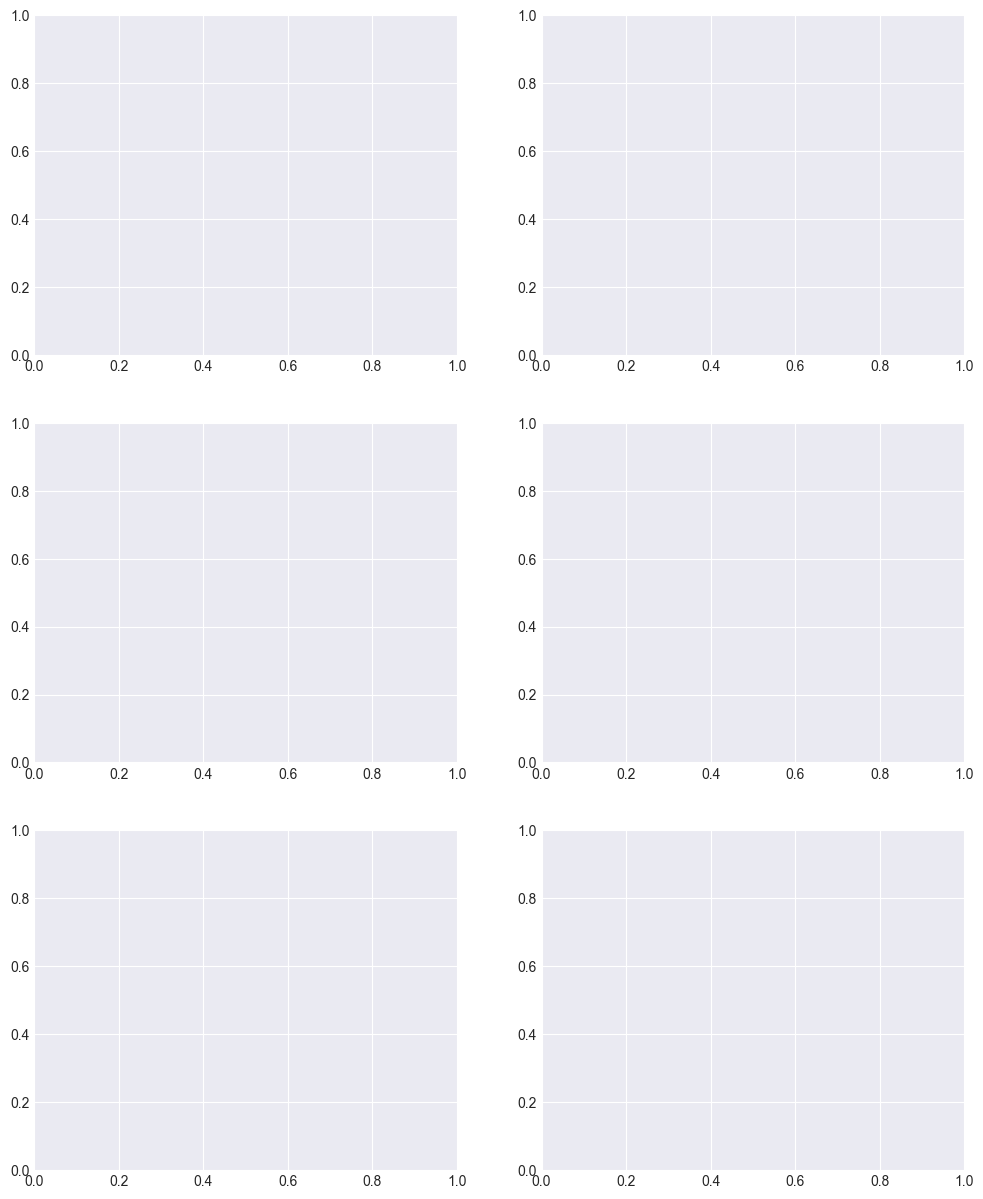

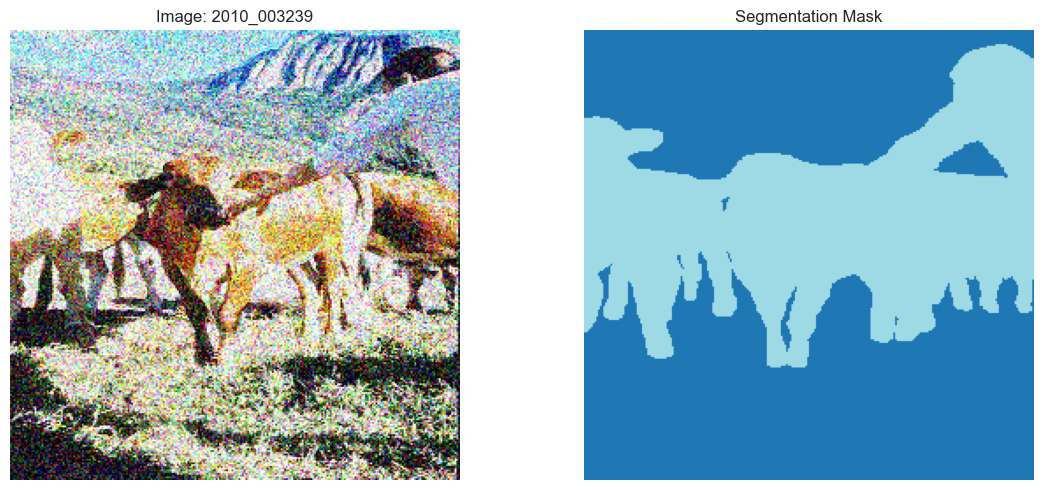

Classes in this image:
  0: background


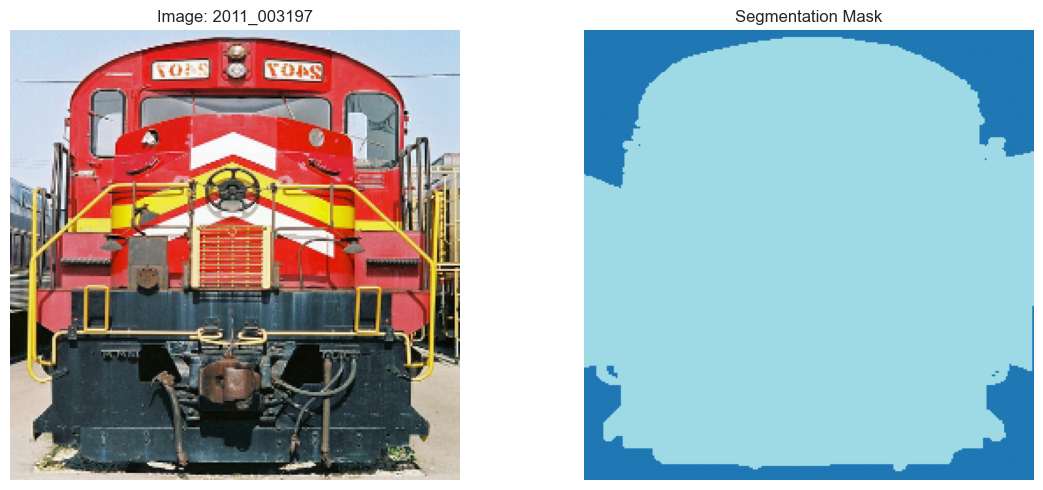

Classes in this image:
  0: background


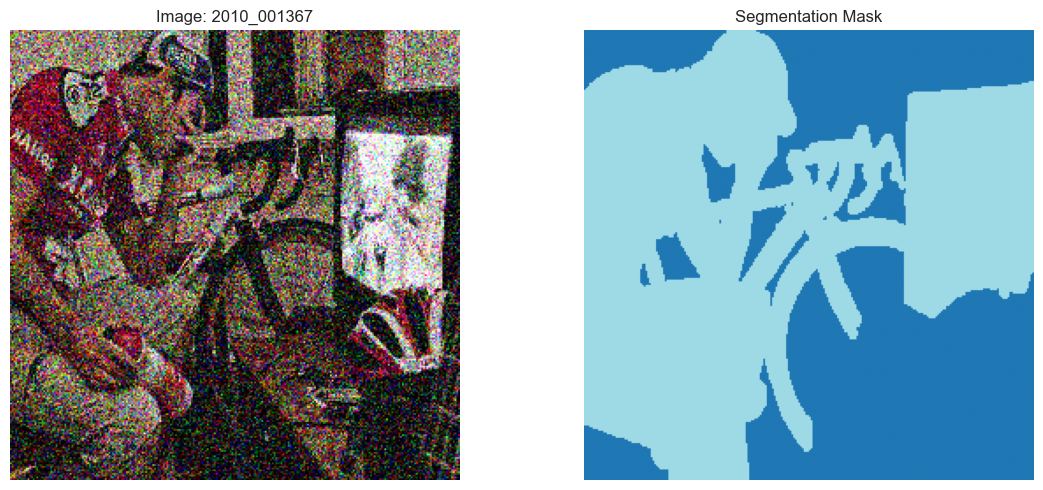

Classes in this image:
  0: background

Visualizing validation samples (no augmentation):


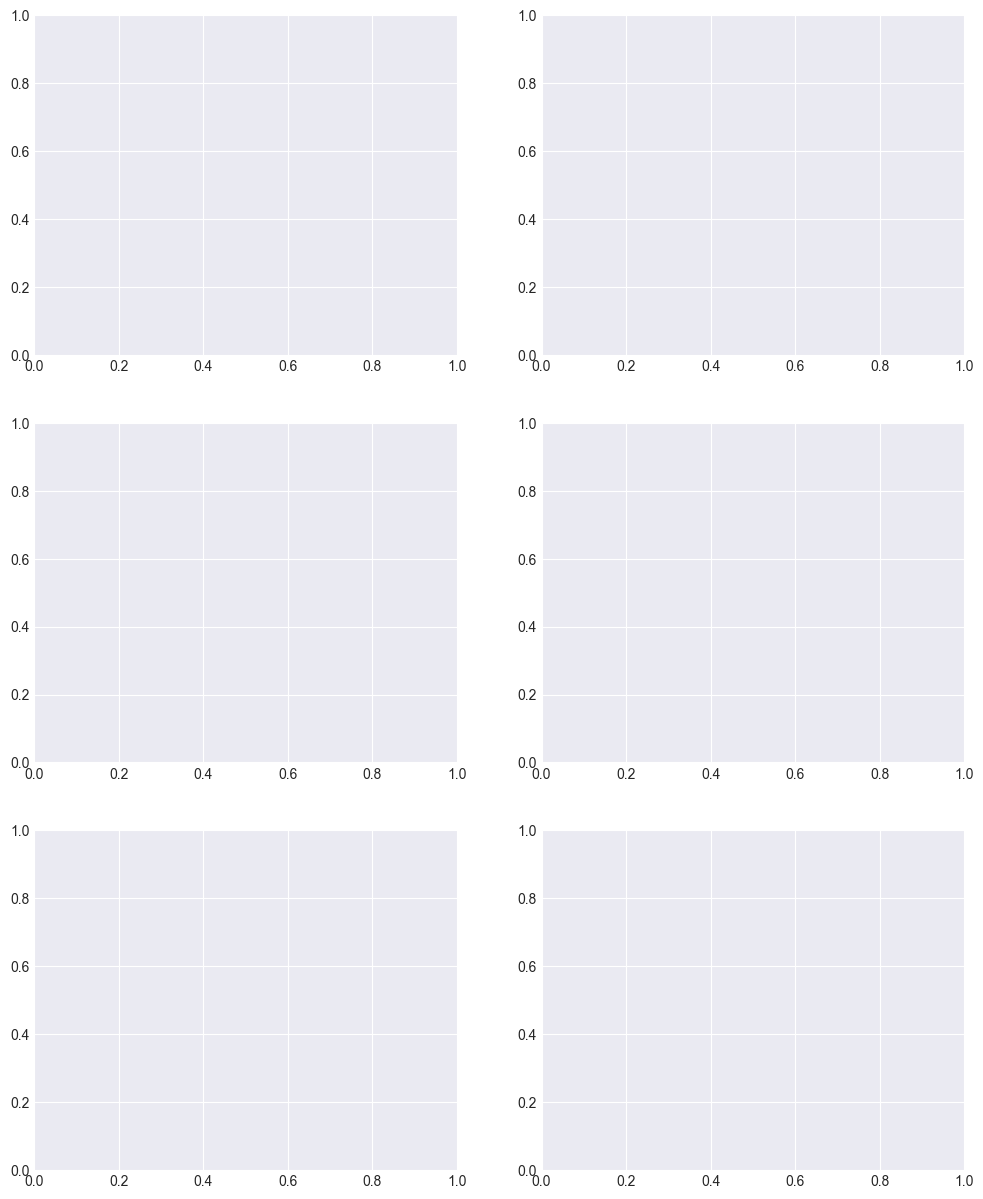

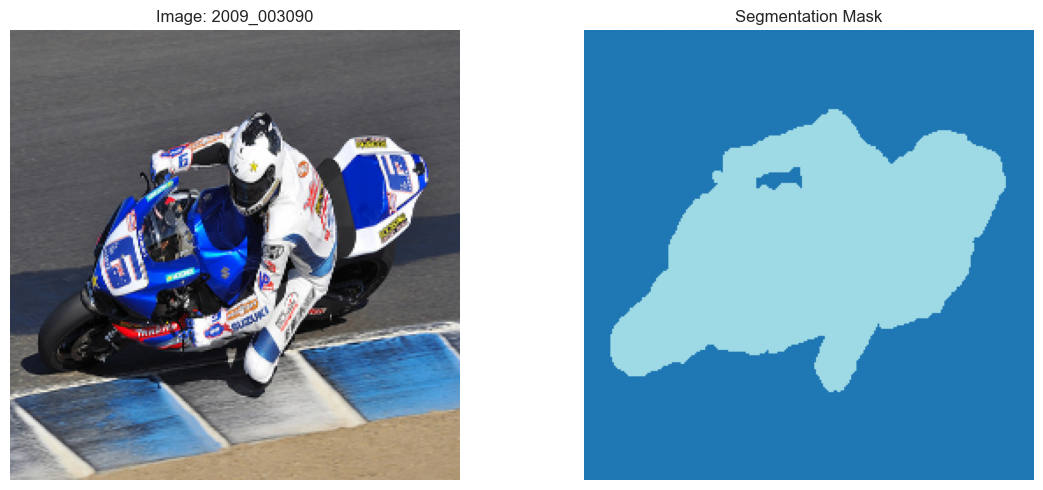

Classes in this image:
  0: background


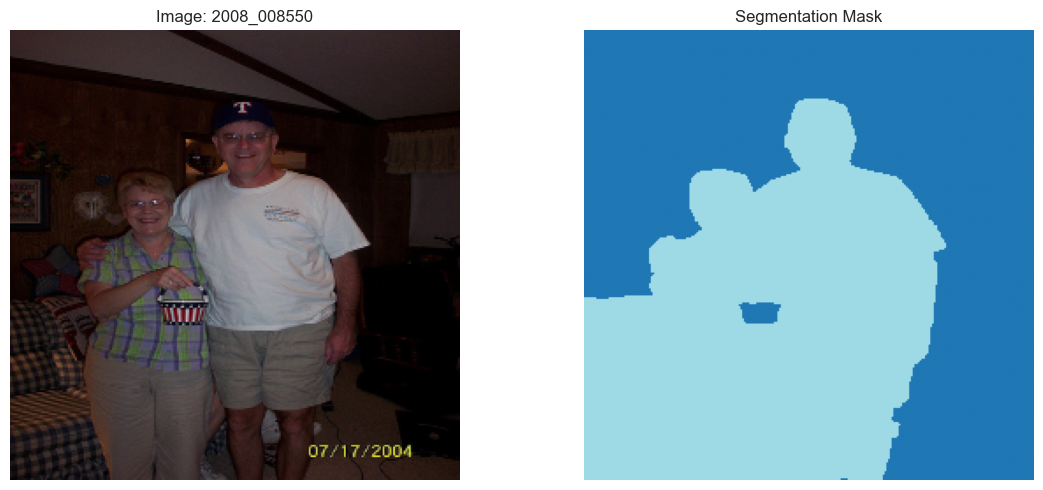

Classes in this image:
  0: background


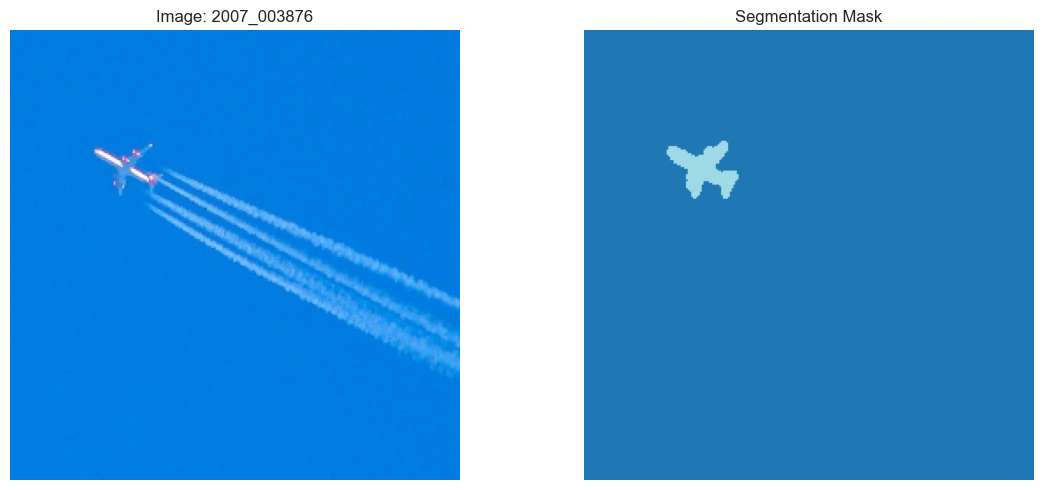

Classes in this image:
  0: background


In [16]:
def visualize_augmentations(dataset, num_samples=4):
    """Visualize augmented samples from dataset"""
    
    fig, axes = plt.subplots(num_samples, 2, figsize=(12, 5*num_samples))
    
    for i in range(num_samples):
        idx = np.random.randint(0, len(dataset))
        dataset.visualize_sample(idx)

print("Visualizing training samples (with augmentation):")
visualize_augmentations(train_dataset, num_samples=3)

print("\nVisualizing validation samples (no augmentation):")
visualize_augmentations(val_dataset, num_samples=3)

In [17]:
# Test a batch from train loader
print("Testing DataLoader...")
images, masks = next(iter(train_loader))

print(f"\n✓ Batch loaded successfully!")
print(f"   Images shape: {images.shape}")  # Should be [batch_size, 3, 256, 256]
print(f"   Masks shape: {masks.shape}")    # Should be [batch_size, 256, 256]
print(f"   Images dtype: {images.dtype}")  # Should be torch.float32
print(f"   Masks dtype: {masks.dtype}")    # Should be torch.int64
print(f"   Images range: [{images.min():.2f}, {images.max():.2f}]")
print(f"   Masks unique values: {torch.unique(masks).tolist()}")

Testing DataLoader...

✓ Batch loaded successfully!
   Images shape: torch.Size([8, 3, 256, 256])
   Masks shape: torch.Size([8, 256, 256])
   Images dtype: torch.float32
   Masks dtype: torch.int64
   Images range: [-2.12, 2.64]
   Masks unique values: [0, 19, 33, 57, 75, 94, 128, 147, 220]


## U-Net Implementation & Training:

In [22]:
import torch.nn.functional as F
import torch.optim as optim
from datetime import datetime
import time
import json
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Using device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")


✓ Using device: cpu


### U-Net Architecture implementing

In [23]:
class DoubleConv(nn.Module):
    """(Conv2D -> BatchNorm -> ReLU) * 2"""
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.double_conv(x)


class Down(nn.Module):
    """Downscaling with maxpool then double conv"""
    def __init__(self, in_channels, out_channels):
        super(Down, self).__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )
    
    def forward(self, x):
        return self.maxpool_conv(x)


class Up(nn.Module):
    """Upscaling then double conv"""
    def __init__(self, in_channels, out_channels, bilinear=True):
        super(Up, self).__init__()
        
        # Use bilinear upsampling or transposed convolutions
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels)
        else:
            self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)
    
    def forward(self, x1, x2):
        x1 = self.up(x1)
        
        # Handle size mismatch (if input dimensions are not divisible by 16)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        
        # Concatenate skip connection
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv(nn.Module):
    """Final output convolution"""
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
    
    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    """
    U-Net Architecture for Semantic Segmentation
    Paper: https://arxiv.org/abs/1505.04597
    """
    def __init__(self, n_channels=3, n_classes=21, bilinear=True):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear
        
        # Encoder (Downsampling path)
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        factor = 2 if bilinear else 1
        self.down4 = Down(512, 1024 // factor)
        
        # Decoder (Upsampling path)
        self.up1 = Up(1024, 512 // factor, bilinear)
        self.up2 = Up(512, 256 // factor, bilinear)
        self.up3 = Up(256, 128 // factor, bilinear)
        self.up4 = Up(128, 64, bilinear)
        
        # Output
        self.outc = OutConv(64, n_classes)
    
    def forward(self, x):
        # Encoder
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        
        # Decoder with skip connections
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        
        # Output
        logits = self.outc(x)
        return logits

print("✓ U-Net architecture defined")

✓ U-Net architecture defined


In [24]:
# Initialize model
model = UNet(n_channels=3, n_classes=21, bilinear=True).to(device)

# Count parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

total_params = count_parameters(model)
print(f"\n📊 U-Net Model Summary:")
print(f"   Total parameters: {total_params:,}")
print(f"   Model size: ~{total_params * 4 / (1024**2):.2f} MB (FP32)")

# Test forward pass
test_input = torch.randn(1, 3, 256, 256).to(device)
with torch.no_grad():
    test_output = model(test_input)
print(f"\n✓ Forward pass test:")
print(f"   Input shape:  {test_input.shape}")
print(f"   Output shape: {test_output.shape}")
print(f"   Expected:     [1, 21, 256, 256]")


📊 U-Net Model Summary:
   Total parameters: 13,396,629
   Model size: ~51.10 MB (FP32)

✓ Forward pass test:
   Input shape:  torch.Size([1, 3, 256, 256])
   Output shape: torch.Size([1, 21, 256, 256])
   Expected:     [1, 21, 256, 256]


In [25]:
# Load dataset configuration
with open("./data/dataset_config.json", 'r') as f:
    config = json.load(f)

print("📋 Dataset Configuration:")
print(json.dumps(config, indent=2))


print("✓ Data loaded and ready for training")

📋 Dataset Configuration:
{
  "dataset": "PASCAL VOC 2012",
  "num_classes": 21,
  "target_size": [
    256,
    256
  ],
  "batch_size": 8,
  "train_samples": 800,
  "val_samples": 200,
  "classes": [
    "background",
    "aeroplane",
    "bicycle",
    "bird",
    "boat",
    "bottle",
    "bus",
    "car",
    "cat",
    "chair",
    "cow",
    "diningtable",
    "dog",
    "horse",
    "motorbike",
    "person",
    "pottedplant",
    "sheep",
    "sofa",
    "train",
    "tvmonitor"
  ],
  "normalization": {
    "mean": [
      0.485,
      0.456,
      0.406
    ],
    "std": [
      0.229,
      0.224,
      0.225
    ]
  }
}
✓ Data loaded and ready for training


### Loss Function:

In [26]:
class DiceLoss(nn.Module):
    """
    Dice Loss for segmentation
    Better than pure Cross Entropy for imbalanced classes
    """
    def __init__(self, smooth=1.0):
        super(DiceLoss, self).__init__()
        self.smooth = smooth
    
    def forward(self, predictions, targets, num_classes=21):
        # predictions: [B, C, H, W]
        # targets: [B, H, W]
        
        # Convert to one-hot
        targets_one_hot = F.one_hot(targets, num_classes=num_classes)  # [B, H, W, C]
        targets_one_hot = targets_one_hot.permute(0, 3, 1, 2).float()  # [B, C, H, W]
        
        # Softmax on predictions
        predictions = F.softmax(predictions, dim=1)
        
        # Flatten
        predictions = predictions.contiguous().view(-1)
        targets_one_hot = targets_one_hot.contiguous().view(-1)
        
        # Dice coefficient
        intersection = (predictions * targets_one_hot).sum()
        dice = (2. * intersection + self.smooth) / (predictions.sum() + targets_one_hot.sum() + self.smooth)
        
        return 1 - dice


class CombinedLoss(nn.Module):
    """
    Combination of Cross Entropy and Dice Loss
    """
    def __init__(self, ce_weight=0.5, dice_weight=0.5):
        super(CombinedLoss, self).__init__()
        self.ce_weight = ce_weight
        self.dice_weight = dice_weight
        self.ce_loss = nn.CrossEntropyLoss()
        self.dice_loss = DiceLoss()
    
    def forward(self, predictions, targets):
        ce = self.ce_loss(predictions, targets)
        dice = self.dice_loss(predictions, targets)
        return self.ce_weight * ce + self.dice_weight * dice


def calculate_iou(predictions, targets, num_classes=21):
    """
    Calculate mean Intersection over Union (mIoU)
    """
    ious = []
    predictions = predictions.view(-1)
    targets = targets.view(-1)
    
    for cls in range(num_classes):
        pred_inds = predictions == cls
        target_inds = targets == cls
        intersection = (pred_inds[target_inds]).long().sum().item()
        union = pred_inds.long().sum().item() + target_inds.long().sum().item() - intersection
        
        if union == 0:
            ious.append(float('nan'))
        else:
            ious.append(intersection / union)
    
    # Return mean IoU (ignoring NaN values)
    return np.nanmean(ious)


def pixel_accuracy(predictions, targets):
    """Calculate pixel-wise accuracy"""
    correct = (predictions == targets).sum().item()
    total = targets.numel()
    return correct / total


print("✓ Loss functions and metrics defined")
print("   - Cross Entropy Loss")
print("   - Dice Loss")
print("   - Combined Loss (CE + Dice)")
print("   - mIoU metric")
print("   - Pixel Accuracy metric")

✓ Loss functions and metrics defined
   - Cross Entropy Loss
   - Dice Loss
   - Combined Loss (CE + Dice)
   - mIoU metric
   - Pixel Accuracy metric


In [27]:
# Training hyperparameters
LEARNING_RATE = 1e-4
NUM_EPOCHS = 2
PATIENCE = 10  # Early stopping patience

# Loss function
criterion = CombinedLoss(ce_weight=0.5, dice_weight=0.5)

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5, 
)

# Create directory for saving checkpoints
checkpoint_dir = Path("./checkpoints/unet")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

print("✓ Training configuration:")
print(f"   Learning rate: {LEARNING_RATE}")
print(f"   Epochs: {NUM_EPOCHS}")
print(f"   Optimizer: Adam")
print(f"   Loss: Combined (CE + Dice)")
print(f"   Scheduler: ReduceLROnPlateau")
print(f"   Checkpoint dir: {checkpoint_dir}")

✓ Training configuration:
   Learning rate: 0.0001
   Epochs: 2
   Optimizer: Adam
   Loss: Combined (CE + Dice)
   Scheduler: ReduceLROnPlateau
   Checkpoint dir: checkpoints\unet


### Train the model

In [28]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    running_iou = 0.0
    running_acc = 0.0
    
    progress_bar = tqdm(dataloader, desc="Training")
    
    for images, masks in progress_bar:
        images = images.to(device)
        masks = masks.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        # Squeeze the channel dimension (e.g., from [B, 1, H, W] to [B, H, W])
        if masks.dim() == 4 and masks.shape[1] == 1:
            masks = masks.squeeze(1)
        
        # Convert pixel values to class indices.
        # If 0 is background and >0 is object:
        masks = (masks > 0).long() 
        # If 0 is background and 255 is object (and others are noise):
        # masks = (masks > 128).long() # or (masks / 255).long()
        
        # Now, masks should be [B, H, W] with dtype=torch.long and values 0 or 1
        loss = criterion(outputs, masks)
                
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Calculate metrics
        with torch.no_grad():
            preds = torch.argmax(outputs, dim=1)
            iou = calculate_iou(preds, masks)
            acc = pixel_accuracy(preds, masks)
        
        # Update running metrics
        running_loss += loss.item()
        running_iou += iou
        running_acc += acc
        
        # Update progress bar
        progress_bar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'iou': f'{iou:.4f}',
            'acc': f'{acc:.4f}'
        })
    
    # Calculate epoch metrics
    epoch_loss = running_loss / len(dataloader)
    epoch_iou = running_iou / len(dataloader)
    epoch_acc = running_acc / len(dataloader)
    
    return epoch_loss, epoch_iou, epoch_acc


def validate(model, dataloader, criterion, device):
    """Validate model"""
    model.eval()
    running_loss = 0.0
    running_iou = 0.0
    running_acc = 0.0
    
    progress_bar = tqdm(dataloader, desc="Validation")
    
    with torch.no_grad():
        for images, masks in progress_bar:
            images = images.to(device)
            masks = masks.to(device)
            
            # Forward pass
            outputs = model(images)
            # Squeeze the channel dimension (e.g., from [B, 1, H, W] to [B, H, W])
            if masks.dim() == 4 and masks.shape[1] == 1:
                masks = masks.squeeze(1)
            
            # Convert pixel values to class indices.
            # If 0 is background and >0 is object:
            masks = (masks > 0).long() 
            # If 0 is background and 255 is object (and others are noise):
            # masks = (masks > 128).long() # or (masks / 255).long()
            
            # Now, masks should be [B, H, W] with dtype=torch.long and values 0 or 1
            loss = criterion(outputs, masks)
            
            # Calculate metrics
            preds = torch.argmax(outputs, dim=1)
            iou = calculate_iou(preds, masks)
            acc = pixel_accuracy(preds, masks)
            
            # Update running metrics
            running_loss += loss.item()
            running_iou += iou
            running_acc += acc
            
            # Update progress bar
            progress_bar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'iou': f'{iou:.4f}',
                'acc': f'{acc:.4f}'
            })
    
    # Calculate epoch metrics
    epoch_loss = running_loss / len(dataloader)
    epoch_iou = running_iou / len(dataloader)
    epoch_acc = running_acc / len(dataloader)
    
    return epoch_loss, epoch_iou, epoch_acc


def save_checkpoint(model, optimizer, epoch, loss, iou, filepath):
    """Save model checkpoint"""
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
        'iou': iou
    }
    torch.save(checkpoint, filepath)
    print(f"✓ Checkpoint saved: {filepath}")


print("✓ Training functions defined")

✓ Training functions defined


In [29]:
# Training history
history = {
    'train_loss': [],
    'train_iou': [],
    'train_acc': [],
    'val_loss': [],
    'val_iou': [],
    'val_acc': [],
    'learning_rates': []
}

# Best model tracking
best_val_iou = 0.0
patience_counter = 0

print("=" * 80)
print("🚀 STARTING U-NET TRAINING")
print("=" * 80)
print(f"Training on: {device}")
print(f"Total epochs: {NUM_EPOCHS}")
print(f"Batch size: {config['batch_size']}")
print(f"Training samples: {config['train_samples']}")
print(f"Validation samples: {config['val_samples']}")
print("=" * 80)

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 80)
    
    # Train
    train_loss, train_iou, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    
    # Validate
    val_loss, val_iou, val_acc = validate(
        model, val_loader, criterion, device
    )
    
    # Update scheduler
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_iou'].append(train_iou)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_iou'].append(val_iou)
    history['val_acc'].append(val_acc)
    history['learning_rates'].append(current_lr)
    
    # Print epoch summary
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"   Train - Loss: {train_loss:.4f} | IoU: {train_iou:.4f} | Acc: {train_acc:.4f}")
    print(f"   Val   - Loss: {val_loss:.4f} | IoU: {val_iou:.4f} | Acc: {val_acc:.4f}")
    print(f"   LR: {current_lr:.2e}")
    
    # Save best model
    if val_iou > best_val_iou:
        best_val_iou = val_iou
        patience_counter = 0
        save_checkpoint(
            model, optimizer, epoch, val_loss, val_iou,
            checkpoint_dir / "best_unet.pth"
        )
        print(f"   ⭐ New best model! Val IoU: {val_iou:.4f}")
    else:
        patience_counter += 1
        print(f"   Patience: {patience_counter}/{PATIENCE}")
    
    # Early stopping
    if patience_counter >= PATIENCE:
        print(f"\n⚠️  Early stopping triggered after {epoch+1} epochs")
        break
    
    # Save latest checkpoint every 5 epochs
    if (epoch + 1) % 5 == 0:
        save_checkpoint(
            model, optimizer, epoch, val_loss, val_iou,
            checkpoint_dir / f"unet_epoch_{epoch+1}.pth"
        )

# Training complete
elapsed_time = time.time() - start_time
print("\n" + "=" * 80)
print("✓ TRAINING COMPLETE!")
print("=" * 80)
print(f"Total time: {elapsed_time/60:.2f} minutes")
print(f"Best validation IoU: {best_val_iou:.4f}")
print(f"Final learning rate: {current_lr:.2e}")
print("=" * 80)

# Save training history
history_path = checkpoint_dir / "training_history.json"
with open(history_path, 'w') as f:
    json.dump(history, f, indent=4)
print(f"✓ Training history saved: {history_path}")

🚀 STARTING U-NET TRAINING
Training on: cpu
Total epochs: 2
Batch size: 8
Training samples: 800
Validation samples: 200

Epoch 1/2
--------------------------------------------------------------------------------


Validation: 100%|█████████████████████████████████| 25/25 [01:19<00:00,  3.19s/it, loss=1.5299, iou=0.1154, acc=0.6451]



Epoch 1 Summary:
   Train - Loss: 1.7282 | IoU: 0.0485 | Acc: 0.4745
   Val   - Loss: 1.5130 | IoU: 0.1203 | Acc: 0.6745
   LR: 1.00e-04
✓ Checkpoint saved: checkpoints\unet\best_unet.pth
   ⭐ New best model! Val IoU: 0.1203

Epoch 2/2
--------------------------------------------------------------------------------


Validation: 100%|█████████████████████████████████| 25/25 [01:17<00:00,  3.11s/it, loss=1.3299, iou=0.1401, acc=0.6266]



Epoch 2 Summary:
   Train - Loss: 1.4017 | IoU: 0.1661 | Acc: 0.6491
   Val   - Loss: 1.2290 | IoU: 0.2194 | Acc: 0.7115
   LR: 1.00e-04
✓ Checkpoint saved: checkpoints\unet\best_unet.pth
   ⭐ New best model! Val IoU: 0.2194

✓ TRAINING COMPLETE!
Total time: 33.08 minutes
Best validation IoU: 0.2194
Final learning rate: 1.00e-04
✓ Training history saved: checkpoints\unet\training_history.json


## SAM integration

In [38]:
!pip install git+https://github.com/facebookresearch/segment-anything.git


  Cloning https://github.com/facebookresearch/segment-anything.git to c:\users\daksh\appdata\local\temp\pip-req-build-uft7pvs4
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git 'C:\Users\daksh\AppData\Local\Temp\pip-req-build-uft7pvs4'

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor
from PIL import Image
print("✓ SAM libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

✓ SAM libraries imported successfully!
PyTorch version: 2.9.0+cpu
CUDA available: False


In [41]:
# Create directory for SAM checkpoints
sam_checkpoint_dir = "checkpoints/sam"
os.makedirs(sam_checkpoint_dir, exist_ok=True)

# SAM model options:
# - vit_h (huge): Best performance, slowest
# - vit_l (large): Good balance
# - vit_b (base): Fastest, decent performance

# We'll use vit_b for faster inference
model_type = "vit_b"
sam_checkpoint_path = os.path.join(sam_checkpoint_dir, "sam_vit_b_01ec64.pth")

# Download checkpoint if not exists
import os
import urllib.request # <-- Add this import at the top of your cell

# ... (your other code like model_type, sam_checkpoint_dir) ...

sam_checkpoint_path = os.path.join(sam_checkpoint_dir, "sam_vit_b_01ec64.pth")

# Download checkpoint if not exists
if not os.path.exists(sam_checkpoint_path):
    print(f"Downloading SAM {model_type} checkpoint...")
    
    # Define the URL
    url = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth"
    
    # Use Python's built-in urllib to download the file
    try:
        urllib.request.urlretrieve(url, sam_checkpoint_path)
        print("✓ Download complete!")
    except Exception as e:
        print(f"Error downloading file: {e}")
        
else:
    print(f"✓ SAM checkpoint already exists!")

print(f"\nModel type: {model_type}")
print(f"Checkpoint path: {sam_checkpoint_path}")
print(f"\nModel type: {model_type}")
print(f"Checkpoint path: {sam_checkpoint_path}")


✓ Download complete!

Model type: vit_b
Checkpoint path: checkpoints/sam\sam_vit_b_01ec64.pth

Model type: vit_b
Checkpoint path: checkpoints/sam\sam_vit_b_01ec64.pth


In [42]:
print("Loading SAM model...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load SAM model
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint_path)
sam.to(device=device)
sam.eval()

# Create automatic mask generator for zero-shot segmentation
mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=32,
    pred_iou_thresh=0.86,
    stability_score_thresh=0.92,
    crop_n_layers=1,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=100,
)

# Create predictor for point/box prompted segmentation (optional)
predictor = SamPredictor(sam)

print("✓ SAM model loaded successfully!")
print(f"Device: {device}")
print(f"Model parameters: {sum(p.numel() for p in sam.parameters()):,}")

Loading SAM model...
✓ SAM model loaded successfully!
Device: cpu
Model parameters: 93,735,472


In [43]:
def convert_sam_masks_to_semantic(masks, image_shape, num_classes):
    """
    Convert SAM's instance masks to semantic segmentation format
    matching your dataset's classes
    """
    h, w = image_shape[:2]
    semantic_mask = np.zeros((h, w), dtype=np.uint8)
    
    # Sort masks by area (largest first) to handle overlaps
    sorted_masks = sorted(masks, key=lambda x: x['area'], reverse=True)
    
    # Assign each mask to a class (simple heuristic: cycle through classes)
    # In practice, you might want more sophisticated class assignment
    for idx, mask_dict in enumerate(sorted_masks):
        mask = mask_dict['segmentation']
        # Assign to classes cyclically (excluding background class 0)
        class_id = (idx % (num_classes - 1)) + 1
        semantic_mask[mask] = class_id
    
    return semantic_mask


def show_sam_masks(image, masks, title="SAM Masks"):
    """Visualize SAM generated masks"""
    if len(masks) == 0:
        print("No masks found!")
        return
    
    plt.figure(figsize=(12, 8))
    plt.imshow(image)
    
    # Show all masks with random colors
    sorted_masks = sorted(masks, key=(lambda x: x['area']), reverse=True)
    
    ax = plt.gca()
    ax.set_autoscale_on(False)
    
    for mask in sorted_masks:
        m = mask['segmentation']
        color = np.random.random(3)
        img = np.ones((m.shape[0], m.shape[1], 3))
        for i in range(3):
            img[:,:,i] = color[i]
        ax.imshow(np.dstack((img, m*0.5)))
    
    plt.title(f"{title} - {len(masks)} masks detected")
    plt.axis('off')
    plt.tight_layout()
    plt.show()


def sam_inference_single_image(image_path, mask_generator):
    """Run SAM inference on a single image"""
    # Read image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Generate masks
    start_time = time.time()
    masks = mask_generator.generate(image)
    inference_time = time.time() - start_time
    
    return masks, image, inference_time


print("✓ SAM inference utility functions defined!")

✓ SAM inference utility functions defined!


In [44]:
# Get a few sample images from validation set
import glob

# Adjust this path based on your dataset structure
val_images = glob.glob("path/to/your/val/images/*.jpg")[:3]  # Test on 3 images

print(f"Testing SAM on {len(val_images)} sample images...\n")

for img_path in val_images:
    print(f"Processing: {os.path.basename(img_path)}")
    
    # Run SAM inference
    masks, image, inf_time = sam_inference_single_image(img_path, mask_generator)
    
    print(f"  - Masks detected: {len(masks)}")
    print(f"  - Inference time: {inf_time:.3f}s")
    
    # Visualize
    show_sam_masks(image, masks, title=f"SAM Output - {os.path.basename(img_path)}")
    print()

print("✓ Test inference complete!")

Testing SAM on 0 sample images...

✓ Test inference complete!


In [ ]:
# NOTE: Update these paths according to your dataset structure
print("Loading validation set file list...")

# 1. Define the path to your voc_root (it's probably already defined, but make sure)
voc_root = Path("./data/VOCdevkit/VOC2012") 

# 2. Define the path to val.txt
val_list_path = voc_root / "ImageSets" / "Segmentation" / "val.txt"

# 3. Read the filenames from val.txt
try:
    with open(val_list_path, 'r') as f:
        val_filenames = [name.strip() for name in f.readlines()]
except FileNotFoundError:
    print(f"ERROR: Could not find {val_list_path}")
    print("Please make sure the dataset is downloaded and extracted correctly.")
    # Stop execution if file not found
    raise

# 4. Define the base image and mask directories
val_images_dir = voc_root / "JPEGImages"
val_masks_dir = voc_root / "SegmentationClass"

# 5. Build the FULL paths for ONLY the validation files
val_image_paths = [val_images_dir / f"{name}.jpg" for name in val_filenames]
val_mask_paths = [val_masks_dir / f"{name}.png" for name in val_filenames]

# 6. Check the length
print(f"✓ Found {len(val_image_paths)} validation images listed in val.txt.")

# Storage for SAM predictions
sam_predictions = []
sam_inference_times = []
sam_num_masks = []

# Create directory to save SAM predictions
sam_pred_dir = "predictions/sam"
os.makedirs(sam_pred_dir, exist_ok=True)

# Run inference on all validation images
for img_path in tqdm(val_image_paths, desc="SAM Inference"):
    # Run SAM
    masks, image, inf_time = sam_inference_single_image(img_path, mask_generator)
    
    # Convert SAM masks to semantic segmentation format
    # Adjust num_classes based on your dataset
    num_classes = 21  # Example: PASCAL VOC has 21 classes (20 + background)
    semantic_mask = convert_sam_masks_to_semantic(masks, image.shape, num_classes)
    
    # Store results
    sam_predictions.append(semantic_mask)
    sam_inference_times.append(inf_time)
    sam_num_masks.append(len(masks))
    
    # Save prediction
    pred_filename = os.path.basename(img_path).replace('.jpg', '.png')
    cv2.imwrite(os.path.join(sam_pred_dir, pred_filename), semantic_mask)

# Calculate statistics
avg_inference_time = np.mean(sam_inference_times)
avg_num_masks = np.mean(sam_num_masks)
fps = 1.0 / avg_inference_time if avg_inference_time > 0 else 0

print("\n" + "=" * 80)
print("SAM INFERENCE STATISTICS")
print("=" * 80)
print(f"Total images processed: {len(val_image_paths)}")
print(f"Average inference time: {avg_inference_time:.3f}s")
print(f"Average FPS: {fps:.2f}")
print(f"Average masks per image: {avg_num_masks:.1f}")
print(f"Total inference time: {sum(sam_inference_times):.2f}s")
print("=" * 80)

# Save SAM predictions for later evaluation
np.save("predictions/sam/sam_predictions.npy", np.array(sam_predictions))
print("✓ SAM predictions saved!")